   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 7.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [wordcloud]
✅ Setup complete!

Creating Sample WhatsApp Chat Data
✓ Sample chat created: whatsapp_chat.txt

Parsing WhatsApp Chat

✓ Parsed 34 messages

First 5 messages:
        Date   Time Author                                            Message  \
0 2024-01-01  10:30   John                                    Good morning! 😊   
1 2024-01-01  10:32  Sarah                      Hey! How are you doing today?   
2 2024-01-01  10:35   John  I'm great! You look beautiful in your profile ...   
3 2024-01-01  10:40  Sarah            Aww thank you! That's so sweet of you 💕   
4 2024-01-01  11:15   John                                    <Media omitted>   

             DateTime  
0 2024-01-01 10:30:00  
1 2024-01-01 10:32:00  
2 2024-01-01 10:35:00  
3 2024-01-01 10:40:00  
4 2024-01-01 11:15:00  

Authors: ['John', 'Sarah']

1A) PROBLEM STATEMENT

PROBLEM STATEMENT: Fl

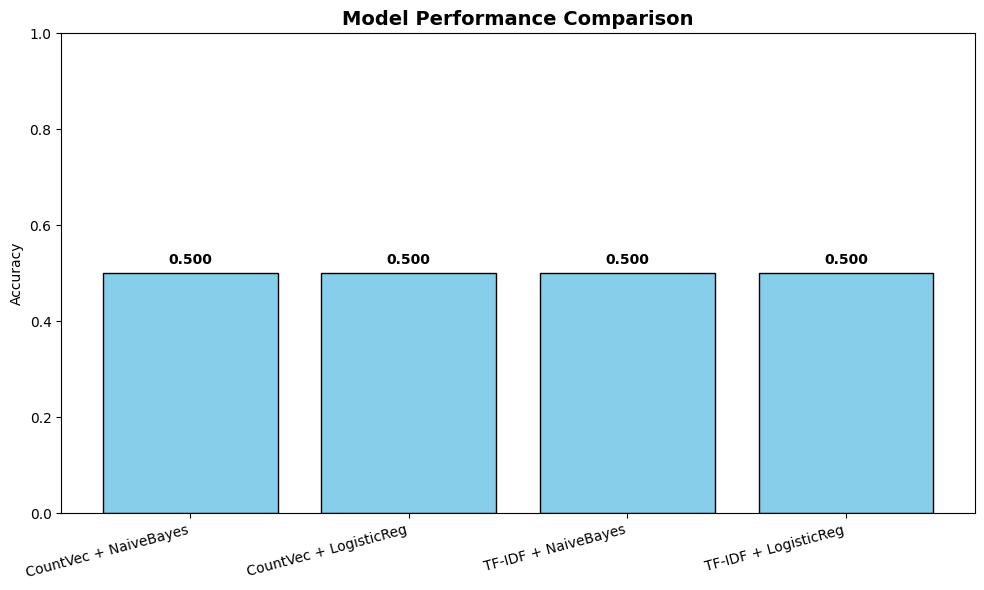


1C) FINAL MODEL

🏆 BEST MODEL: CountVec + NaiveBayes
📊 Accuracy: 0.5000

✓ Final model selected and ready for prediction!

Classification Report:
              precision    recall  f1-score   support

   Not Flirt       0.50      1.00      0.67         3
       Flirt       0.00      0.00      0.00         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



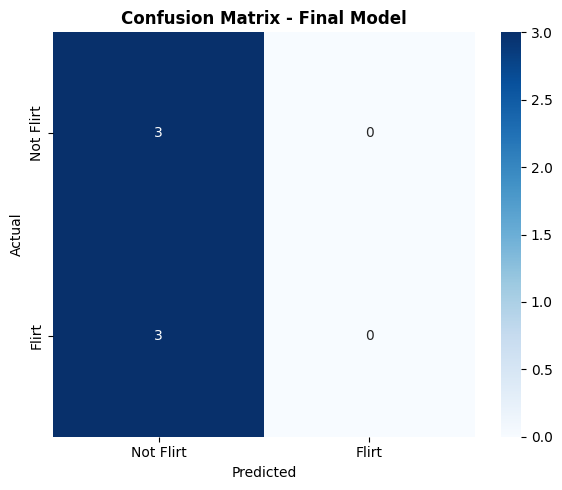


2) APPLY FLIRT MODEL TO WHATSAPP CHAT

Flirt predictions for each message:
Author                                             Message Flirt_Prediction
  John                                     Good morning! 😊        Not Flirt
 Sarah                       Hey! How are you doing today?        Not Flirt
  John I'm great! You look beautiful in your profile pic 😍            Flirt
 Sarah             Aww thank you! That's so sweet of you 💕            Flirt
  John                                     <Media omitted>              N/A
 Sarah                                       Haha love it!        Not Flirt
  John                     Want to grab coffee sometime? ☕            Flirt
 Sarah                            Sure! That would be nice        Not Flirt
  John                                   Missed voice call              N/A
 Sarah                    Sorry missed your call! Was busy        Not Flirt
  John                     No worries! Can I call you now?        Not Flirt
 Sarah      

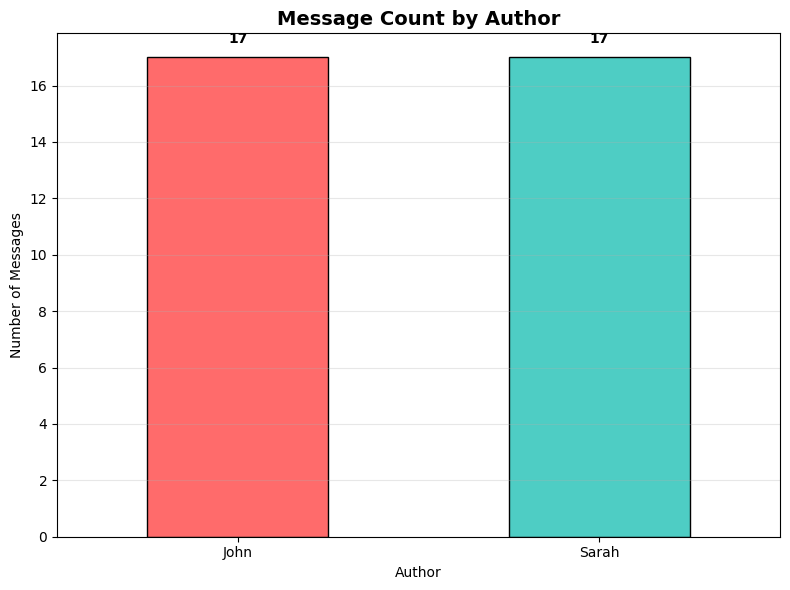


4) MOST ACTIVE DAY & TIME ANALYSIS

📅 Most Active Date: 2024-01-01
   Messages: 12

⏰ Most Active Hour: 10:00
   Messages: 5


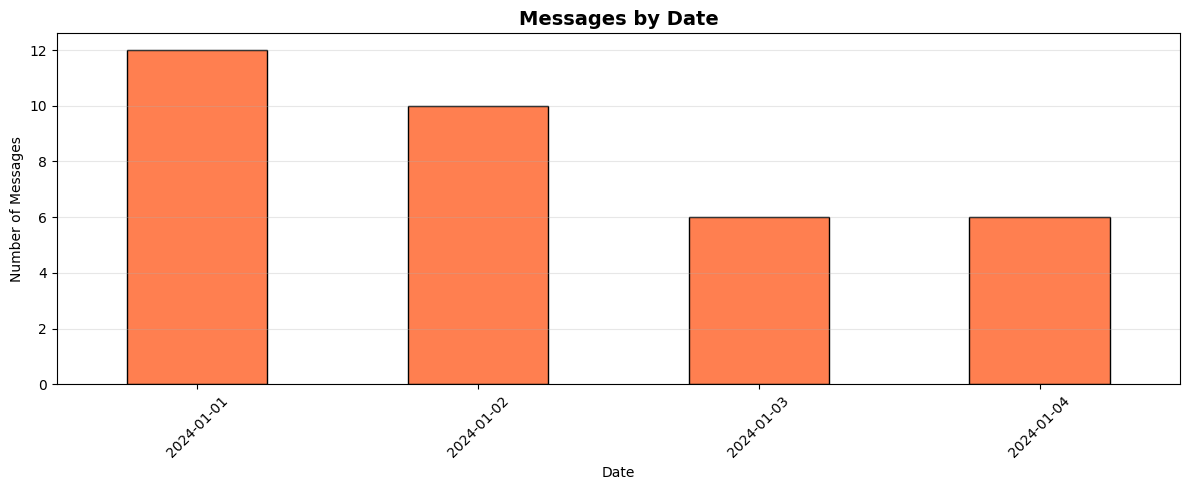

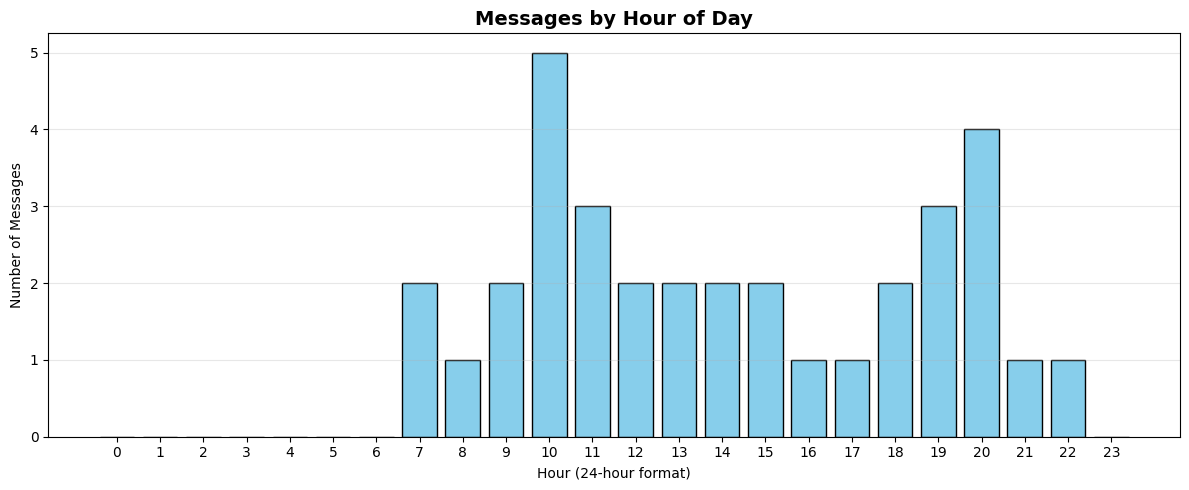


5) MEDIA COUNT SENT BY EACH PERSON

Media files sent by each person:
Author
John     2
Sarah    2
dtype: int64


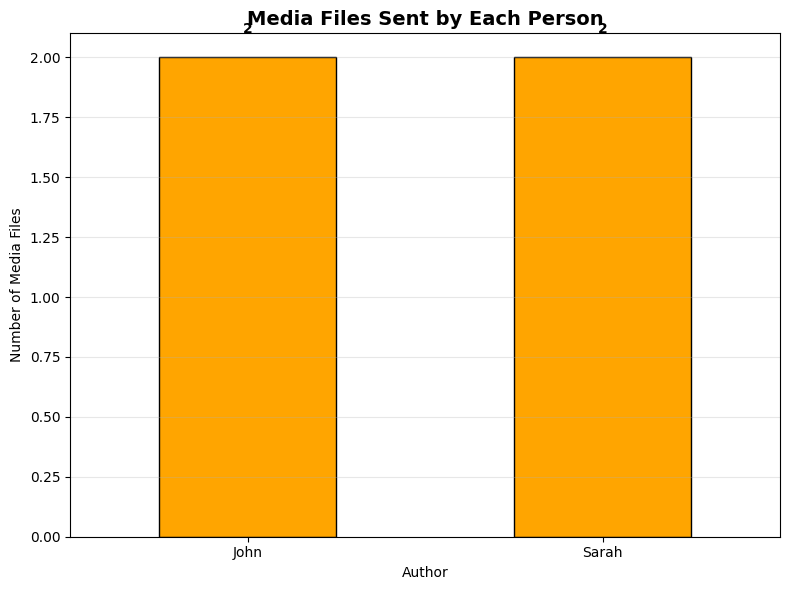


6) MISSED CALLS ANALYSIS

Total missed calls: 4

Missed calls details:
           DateTime Author                          Message
2024-01-01 18:45:00   John                Missed voice call
2024-01-01 19:00:00  Sarah Sorry missed your call! Was busy
2024-01-02 18:00:00   John                Missed video call
2024-01-04 17:00:00   John                Missed voice call

Missed calls by person:
Author
John     3
Sarah    1
dtype: int64


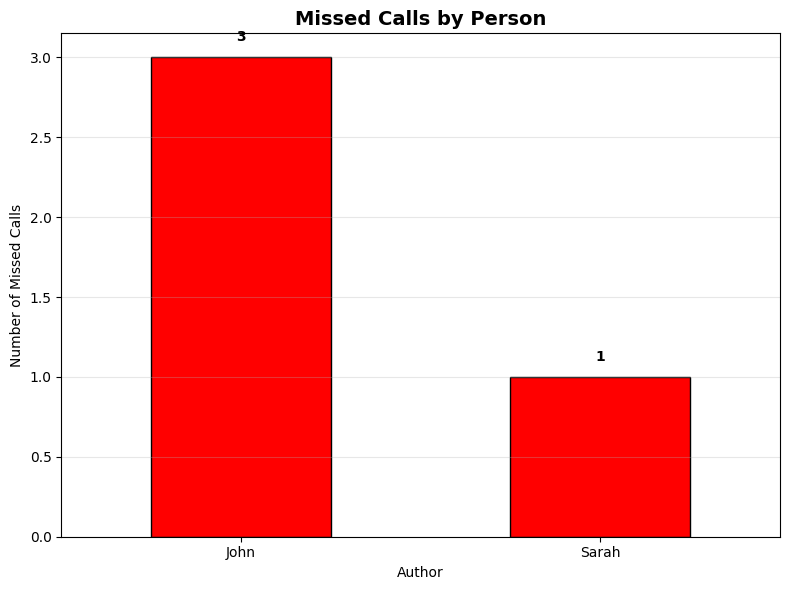


📊 FINAL WHATSAPP CHAT ANALYSIS SUMMARY

CHAT ANALYSIS SUMMARY

1. FLIRT PREDICTION MODEL
   - Best Model: CountVec + NaiveBayes
   - Accuracy: 50.00%
   - Total messages analyzed: 34
   - Flirty messages detected: 6

2. CONVERSATION PARTICIPANTS
   - John, Sarah

3. TALKATIVE ANALYSIS
   - Most Talkative: John (17 messages)
   - Less Talkative: John (17 messages)

4. ACTIVITY PATTERNS
   - Most Active Date: 2024-01-01
   - Most Active Hour: 10:00

5. MEDIA SHARING
   - Total media files: 4
      - John: 2
   - Sarah: 2

6. MISSED CALLS
   - Total: 4
      - John: 3
   - Sarah: 1


✅ Summary saved to: chat_analysis_summary.txt

EXPORTING RESULTS
✓ Detailed results exported: whatsapp_analysis_results.csv

🎉 ANALYSIS COMPLETE!

📁 Generated Files:
   1. whatsapp_chat.txt (input)
   2. chat_analysis_summary.txt (summary)
   3. whatsapp_analysis_results.csv (detailed results)


In [1]:
# ============================================================================
# WHATSAPP CHAT ANALYSIS WITH FLIRT PREDICTION
# Complete NLP Analysis Pipeline
# ============================================================================

# CELL 1: Install and Import Everything
# ============================================================================
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud emoji

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")

# ============================================================================
# STEP 1: CREATE SAMPLE WHATSAPP CHAT DATA
# ============================================================================
print("\n" + "="*60)
print("Creating Sample WhatsApp Chat Data")
print("="*60)

# Create sample chat data
sample_chat = """01/01/2024, 10:30 - John: Good morning! 😊
01/01/2024, 10:32 - Sarah: Hey! How are you doing today?
01/01/2024, 10:35 - John: I'm great! You look beautiful in your profile pic 😍
01/01/2024, 10:40 - Sarah: Aww thank you! That's so sweet of you 💕
01/01/2024, 11:15 - John: <Media omitted>
01/01/2024, 11:20 - Sarah: Haha love it!
01/01/2024, 14:30 - John: Want to grab coffee sometime? ☕
01/01/2024, 14:35 - Sarah: Sure! That would be nice
01/01/2024, 18:45 - John: Missed voice call
01/01/2024, 19:00 - Sarah: Sorry missed your call! Was busy
01/01/2024, 19:05 - John: No worries! Can I call you now?
01/01/2024, 20:30 - Sarah: <Media omitted>
02/01/2024, 09:00 - John: Good morning sunshine! ☀️
02/01/2024, 09:15 - Sarah: Morning! 😊
02/01/2024, 12:00 - John: Thinking about you
02/01/2024, 12:30 - Sarah: You're so cute! 💗
02/01/2024, 15:00 - John: Can't wait to see you
02/01/2024, 15:10 - Sarah: Me too!
02/01/2024, 18:00 - John: Missed video call
02/01/2024, 20:00 - Sarah: What are you doing?
02/01/2024, 20:05 - John: Just thinking about our date 😉
02/01/2024, 20:10 - Sarah: <Media omitted>
03/01/2024, 08:30 - John: You're amazing! 💖
03/01/2024, 10:00 - Sarah: Thanks! How's work?
03/01/2024, 11:00 - John: Boring without you
03/01/2024, 16:00 - Sarah: Haha you're funny
03/01/2024, 19:00 - John: <Media omitted>
03/01/2024, 21:00 - Sarah: That's hilarious! 😂
04/01/2024, 07:00 - John: Good morning gorgeous! 🌹
04/01/2024, 07:30 - Sarah: Morning! 💕
04/01/2024, 13:00 - John: Lunch?
04/01/2024, 13:05 - Sarah: Can't today, maybe tomorrow?
04/01/2024, 17:00 - John: Missed voice call
04/01/2024, 22:00 - Sarah: Good night! Sweet dreams"""

# Save to file
with open('whatsapp_chat.txt', 'w', encoding='utf-8') as f:
    f.write(sample_chat)

print("✓ Sample chat created: whatsapp_chat.txt")

# ============================================================================
# STEP 2: PARSE WHATSAPP CHAT
# ============================================================================
print("\n" + "="*60)
print("Parsing WhatsApp Chat")
print("="*60)

def parse_whatsapp_chat(file_path):
    """Parse WhatsApp chat into DataFrame"""
    
    with open(file_path, 'r', encoding='utf-8') as f:
        data = f.read()
    
    # Pattern to match WhatsApp messages
    pattern = r'(\d{2}/\d{2}/\d{4}), (\d{2}:\d{2}) - ([^:]+): (.+)'
    
    matches = re.findall(pattern, data)
    
    df = pd.DataFrame(matches, columns=['Date', 'Time', 'Author', 'Message'])
    
    # Convert to datetime
    df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], 
                                     format='%d/%m/%Y %H:%M')
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    
    return df

df = parse_whatsapp_chat('whatsapp_chat.txt')

print(f"\n✓ Parsed {len(df)} messages")
print(f"\nFirst 5 messages:")
print(df.head())

print(f"\nAuthors: {df['Author'].unique().tolist()}")

# ============================================================================
# PART 1A: PROBLEM STATEMENT
# ============================================================================
print("\n" + "="*60)
print("1A) PROBLEM STATEMENT")
print("="*60)

problem_statement = """
PROBLEM STATEMENT: Flirt Prediction in WhatsApp Chats

OBJECTIVE: 
Build a machine learning model to identify flirtatious messages in WhatsApp 
conversations.

DEFINITION OF FLIRTING:
Messages containing:
- Romantic language (love, beautiful, gorgeous, cute)
- Emojis (❤️, 😍, 💕, 😘, 🥰)
- Compliments
- Expressions of attraction
- Dating-related content (coffee, date, meet)

USE CASE:
Automatically detect the nature of conversation for chat analysis and 
relationship insights.
"""

print(problem_statement)

# ============================================================================
# PART 1B: RESEARCH METHODOLOGY
# ============================================================================
print("\n" + "="*60)
print("1B) RESEARCH METHODOLOGY")
print("="*60)

# Create training data
flirt_keywords = [
    'beautiful', 'gorgeous', 'cute', 'amazing', 'sweet', 'love',
    'thinking about you', 'miss you', 'cant wait', 'stunning',
    'attractive', 'handsome', 'pretty', 'date', 'coffee'
]

def label_message(message):
    """Label message as flirt (1) or not flirt (0)"""
    message_lower = message.lower()
    
    # Check for flirt keywords
    if any(keyword in message_lower for keyword in flirt_keywords):
        return 1
    
    # Check for romantic emojis
    romantic_emojis = ['😍', '💕', '❤️', '😘', '💖', '💗', '🥰', '💘', '🌹']
    if any(emoji in message for emoji in romantic_emojis):
        return 1
    
    return 0

# Label the data
df['is_flirt'] = df['Message'].apply(label_message)

print(f"Total messages: {len(df)}")
print(f"Flirt messages: {df['is_flirt'].sum()}")
print(f"Non-flirt messages: {(df['is_flirt'] == 0).sum()}")

# Filter out system messages
df_clean = df[~df['Message'].str.contains('<Media omitted>|Missed', case=False)].copy()

print(f"\nClean messages for training: {len(df_clean)}")

# Prepare data
X = df_clean['Message']
y = df_clean['is_flirt']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)} messages")
print(f"Test set: {len(X_test)} messages")

# ============================================================================
# MODEL 1: Count Vectorizer + Naive Bayes
# ============================================================================
print("\n" + "-"*60)
print("MODEL 1: Count Vectorizer + Naive Bayes")
print("-"*60)

cv = CountVectorizer(max_features=100)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_cv, y_train)
y_pred_nb = nb_model.predict(X_test_cv)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy: {acc_nb:.4f}")

# ============================================================================
# MODEL 2: Count Vectorizer + Logistic Regression
# ============================================================================
print("\n" + "-"*60)
print("MODEL 2: Count Vectorizer + Logistic Regression")
print("-"*60)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_cv, y_train)
y_pred_lr = lr_model.predict(X_test_cv)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.4f}")

# ============================================================================
# MODEL 3: TF-IDF + Naive Bayes
# ============================================================================
print("\n" + "-"*60)
print("MODEL 3: TF-IDF Vectorizer + Naive Bayes")
print("-"*60)

tfidf = TfidfVectorizer(max_features=100)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

nb_tfidf_model = MultinomialNB()
nb_tfidf_model.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf_model.predict(X_test_tfidf)

acc_nb_tfidf = accuracy_score(y_test, y_pred_nb_tfidf)
print(f"Accuracy: {acc_nb_tfidf:.4f}")

# ============================================================================
# MODEL 4: TF-IDF + Logistic Regression
# ============================================================================
print("\n" + "-"*60)
print("MODEL 4: TF-IDF Vectorizer + Logistic Regression")
print("-"*60)

lr_tfidf_model = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf_model.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf_model.predict(X_test_tfidf)

acc_lr_tfidf = accuracy_score(y_test, y_pred_lr_tfidf)
print(f"Accuracy: {acc_lr_tfidf:.4f}")

# ============================================================================
# COMPARE ALL MODELS
# ============================================================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

results = pd.DataFrame({
    'Model': [
        'CountVec + NaiveBayes',
        'CountVec + LogisticReg',
        'TF-IDF + NaiveBayes',
        'TF-IDF + LogisticReg'
    ],
    'Accuracy': [acc_nb, acc_lr, acc_nb_tfidf, acc_lr_tfidf]
})

print(results.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Accuracy'], color='skyblue', edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison', fontweight='bold', fontsize=14)
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# PART 1C: FINAL MODEL SELECTION
# ============================================================================
print("\n" + "="*60)
print("1C) FINAL MODEL")
print("="*60)

# Select best model
best_idx = results['Accuracy'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_accuracy = results.loc[best_idx, 'Accuracy']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"📊 Accuracy: {best_accuracy:.4f}")

# Use TF-IDF + Logistic Regression as final model
final_vectorizer = tfidf
final_model = lr_tfidf_model

print("\n✓ Final model selected and ready for prediction!")

# Detailed evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tfidf, 
                           target_names=['Not Flirt', 'Flirt']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_tfidf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Flirt', 'Flirt'],
            yticklabels=['Not Flirt', 'Flirt'])
plt.title('Confusion Matrix - Final Model', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ============================================================================
# PART 2: APPLY FLIRT MODEL TO EACH WHATSAPP MESSAGE
# ============================================================================
print("\n" + "="*60)
print("2) APPLY FLIRT MODEL TO WHATSAPP CHAT")
print("="*60)

def predict_flirt(message):
    """Predict if message is flirty"""
    if '<Media omitted>' in message or 'Missed' in message:
        return 'N/A'
    
    msg_vec = final_vectorizer.transform([message])
    prediction = final_model.predict(msg_vec)[0]
    return 'Flirt' if prediction == 1 else 'Not Flirt'

# Apply to all messages
df['Flirt_Prediction'] = df['Message'].apply(predict_flirt)

print("\nFlirt predictions for each message:")
print(df[['Author', 'Message', 'Flirt_Prediction']].to_string(index=False))

# Summary by author
print("\n" + "-"*60)
flirt_by_author = df[df['Flirt_Prediction'] == 'Flirt'].groupby('Author').size()
print("\nFlirty messages by author:")
print(flirt_by_author)

# ============================================================================
# PART 3: TALKATIVE VS LESS TALKATIVE
# ============================================================================
print("\n" + "="*60)
print("3) TALKATIVE VS LESS TALKATIVE ANALYSIS")
print("="*60)

message_counts = df.groupby('Author').size().sort_values(ascending=False)

print("\nMessage count by author:")
print(message_counts)

most_talkative = message_counts.idxmax()
less_talkative = message_counts.idxmin()

print(f"\n🗣️  Most Talkative: {most_talkative} ({message_counts.max()} messages)")
print(f"🤐 Less Talkative: {less_talkative} ({message_counts.min()} messages)")

# Visualize
plt.figure(figsize=(8, 6))
message_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
plt.title('Message Count by Author', fontweight='bold', fontsize=14)
plt.ylabel('Number of Messages')
plt.xlabel('Author')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(message_counts):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# PART 4: MOST ACTIVE DAY & TIME
# ============================================================================
print("\n" + "="*60)
print("4) MOST ACTIVE DAY & TIME ANALYSIS")
print("="*60)

# Most active day
df['DayOfWeek'] = df['DateTime'].dt.day_name()
df['DateOnly'] = df['Date'].dt.date

messages_by_date = df.groupby('DateOnly').size().sort_values(ascending=False)
most_active_date = messages_by_date.idxmax()

print(f"\n📅 Most Active Date: {most_active_date}")
print(f"   Messages: {messages_by_date.max()}")

# Most active hour
df['Hour'] = df['DateTime'].dt.hour
messages_by_hour = df.groupby('Hour').size().sort_values(ascending=False)
most_active_hour = messages_by_hour.idxmax()

print(f"\n⏰ Most Active Hour: {most_active_hour}:00")
print(f"   Messages: {messages_by_hour.max()}")

# Visualize by date
plt.figure(figsize=(12, 5))
messages_by_date.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Messages by Date', fontweight='bold', fontsize=14)
plt.ylabel('Number of Messages')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize by hour
plt.figure(figsize=(12, 5))
hours = range(24)
hour_counts = [messages_by_hour.get(h, 0) for h in hours]
plt.bar(hours, hour_counts, color='skyblue', edgecolor='black')
plt.title('Messages by Hour of Day', fontweight='bold', fontsize=14)
plt.ylabel('Number of Messages')
plt.xlabel('Hour (24-hour format)')
plt.xticks(hours)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# PART 5: MEDIA COUNT BY PERSON
# ============================================================================
print("\n" + "="*60)
print("5) MEDIA COUNT SENT BY EACH PERSON")
print("="*60)

media_df = df[df['Message'].str.contains('<Media omitted>', case=False)]
media_by_author = media_df.groupby('Author').size().sort_values(ascending=False)

print("\nMedia files sent by each person:")
print(media_by_author)

if len(media_by_author) > 0:
    # Visualize
    plt.figure(figsize=(8, 6))
    media_by_author.plot(kind='bar', color='orange', edgecolor='black')
    plt.title('Media Files Sent by Each Person', fontweight='bold', fontsize=14)
    plt.ylabel('Number of Media Files')
    plt.xlabel('Author')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(media_by_author):
        plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No media files in chat")

# ============================================================================
# PART 6: MISSED CALLS
# ============================================================================
print("\n" + "="*60)
print("6) MISSED CALLS ANALYSIS")
print("="*60)

missed_calls = df[df['Message'].str.contains('Missed', case=False)]

print(f"\nTotal missed calls: {len(missed_calls)}")

if len(missed_calls) > 0:
    print("\nMissed calls details:")
    print(missed_calls[['DateTime', 'Author', 'Message']].to_string(index=False))
    
    missed_by_author = missed_calls.groupby('Author').size()
    print(f"\nMissed calls by person:")
    print(missed_by_author)
    
    # Visualize
    plt.figure(figsize=(8, 6))
    missed_by_author.plot(kind='bar', color='red', edgecolor='black')
    plt.title('Missed Calls by Person', fontweight='bold', fontsize=14)
    plt.ylabel('Number of Missed Calls')
    plt.xlabel('Author')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(missed_by_author):
        plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No missed calls in chat")

# ============================================================================
# FINAL SUMMARY REPORT
# ============================================================================
print("\n" + "="*60)
print("📊 FINAL WHATSAPP CHAT ANALYSIS SUMMARY")
print("="*60)

summary = f"""
CHAT ANALYSIS SUMMARY
{'='*60}

1. FLIRT PREDICTION MODEL
   - Best Model: {best_model_name}
   - Accuracy: {best_accuracy:.2%}
   - Total messages analyzed: {len(df)}
   - Flirty messages detected: {(df['Flirt_Prediction'] == 'Flirt').sum()}

2. CONVERSATION PARTICIPANTS
   - {', '.join(df['Author'].unique())}

3. TALKATIVE ANALYSIS
   - Most Talkative: {most_talkative} ({message_counts.max()} messages)
   - Less Talkative: {less_talkative} ({message_counts.min()} messages)

4. ACTIVITY PATTERNS
   - Most Active Date: {most_active_date}
   - Most Active Hour: {most_active_hour}:00

5. MEDIA SHARING
   - Total media files: {len(media_df)}
   {chr(10).join([f'   - {author}: {count}' for author, count in media_by_author.items()]) if len(media_by_author) > 0 else '   - None'}

6. MISSED CALLS
   - Total: {len(missed_calls)}
   {chr(10).join([f'   - {author}: {count}' for author, count in missed_by_author.items()]) if len(missed_calls) > 0 else '   - None'}

{'='*60}
"""

print(summary)

# Save summary to file
with open('chat_analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("✅ Summary saved to: chat_analysis_summary.txt")

# ============================================================================
# EXPORT RESULTS
# ============================================================================
print("\n" + "="*60)
print("EXPORTING RESULTS")
print("="*60)

# Export analyzed data
df_export = df[['DateTime', 'Author', 'Message', 'Flirt_Prediction']]
df_export.to_csv('whatsapp_analysis_results.csv', index=False)
print("✓ Detailed results exported: whatsapp_analysis_results.csv")

print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE!")
print("="*60)
print("\n📁 Generated Files:")
print("   1. whatsapp_chat.txt (input)")
print("   2. chat_analysis_summary.txt (summary)")
print("   3. whatsapp_analysis_results.csv (detailed results)")